Please upload your .txt or .out log file:


Saving train.out to train (2).out


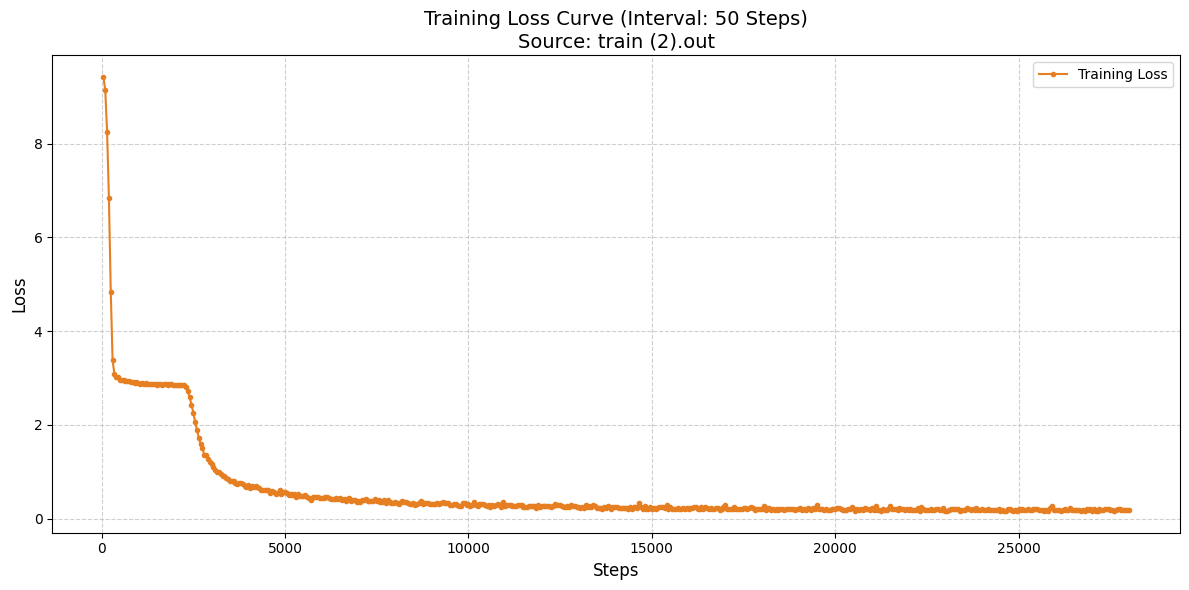

In [3]:
import matplotlib.pyplot as plt
import ast
from google.colab import files

# Step 1: Upload the file from your computer
print("Please upload your .txt or .out log file:")
uploaded = files.upload()

if not uploaded:
    print("No file uploaded.")
else:
    # Get the filename of the uploaded file
    filename = list(uploaded.keys())[0]

    # Initialize lists to store our values
    steps = []
    losses = []
    current_step = 0

    # Step 2: Read and parse the file
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            try:
                # Convert the line string into a Python dictionary
                entry = ast.literal_eval(line)

                # Filter: Only process lines containing 'loss' (skips 'eval_loss')
                if 'loss' in entry:
                    # Increment step counter by 50 for every loss entry
                    current_step += 50
                    steps.append(current_step)
                    losses.append(float(entry['loss']))

            except (ValueError, SyntaxError):
                # Skip lines that are not valid dictionary formats
                continue

    # Step 3: Create the plot
    if steps and losses:
        plt.figure(figsize=(12, 6))
        plt.plot(steps, losses, marker='.', linestyle='-', color='#e67e22', label='Training Loss')

        # Adding labels and styling
        plt.title(f'Training Loss Curve (Interval: 50 Steps)\nSource: {filename}', fontsize=14)
        plt.xlabel('Steps', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.legend()

        # Optional: Adjust x-axis to show steps more clearly if the list is long
        plt.tight_layout()

        plt.show()
    else:
        print("No valid training data found. Ensure the file contains lines like: {'loss': '0.1943', ...}")